# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024170417         # <-- your full roll number
NAME = "Anvi"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024170417   Name: Anvi   Fingerprint: 53482F17   Tickets: 14

Ticket_ID                                                                       Ticket_Text
      T01    Server was working yesterday after resetting my password. It worked yesterday.
      T02            Server has stopped syncing since yesterday. I don't know what changed.
      T03                                             It's not the laptop; it's the server.
      T04                                             I tried again... still no response!!!
      T05                                                       The file is 95.5% uploaded.
      T06                     The password is running slowly. It works on another computer.
      T07              Matlab crashes while opening when I use mobile hotspot. Please help.
      T08                           The password failed to open. Is there another solution?
      T09       Printer has stopped syncing before the assignment deadline. This is urgent.
    

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [9]:
# Enter your roll number
roll_no = input("Enter your roll number: ")

# Generate dataset
tickets, focus_ticket_ids, fingerprint = generate_dataset(roll_no)

print("Fingerprint:", fingerprint)
print("Number of tickets:", len(tickets))


# Process every ticket
data = []

for i, ticket in enumerate(tickets, 1):
    result = process_ticket(ticket)

    data.append({
        "Ticket": i,
        "Number of Sentences": len(result["sentences"]),
        "Number of Tokens": len(result["tokens"]),
        "Number of Punctuation Tokens": len(result["punct"]),
        "Number of Stopwords": len(result["stops"]),
        "Number of Unique Tokens": len(set(result["tokens"])),
        "Number of Final Tokens": len(result["final"])
    })


# Create table
df = pd.DataFrame(data)

# Add total row
total_row = {
    "Ticket": "TOTAL",
    "Number of Sentences": df["Number of Sentences"].sum(),
    "Number of Tokens": df["Number of Tokens"].sum(),
    "Number of Punctuation Tokens": df["Number of Punctuation Tokens"].sum(),
    "Number of Stopwords": df["Number of Stopwords"].sum(),
    "Number of Unique Tokens": df["Number of Unique Tokens"].sum(),
    "Number of Final Tokens": df["Number of Final Tokens"].sum()
}

df.loc[len(df)] = total_row

display(df)


# Selected ticket
ticket_no = 1
result = process_ticket(tickets[ticket_no - 1])

print("\nSelected Ticket:", ticket_no)

print("\nActual Tokens:")
print(result["tokens"])

print("\nPunctuation Tokens:")
print(result["punct"])

print("\nStopwords:")
print(result["stops"])

print("\nFinal Tokens:")
print(result["final"])

Enter your roll number: 1024170417
Fingerprint: 53482F17
Number of tickets: 14


,Ticket,Number of Sentences,Number of Tokens,Number of Punctuation Tokens,Number of Stopwords,Number of Unique Tokens,Number of Final Tokens
0,1,1,1,0,0,1,1
1,2,1,1,0,0,1,1
2,TOTAL,2,2,0,0,2,2


KeyError: 0

**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [11]:
import re
import pandas as pd

# ============================================================
# Q2 - REGULAR EXPRESSIONS
# ============================================================

# ------------------------------------------------------------
# 1. REGEX PATTERNS FOR EXTRACTION
# ------------------------------------------------------------

# Words longer than 5 letters
long_words_pattern = r"\b[A-Za-z]{6,}\b"

# Numbers, decimals and versions
# Examples: 95, 95.5, 2.0.1, 1,250
numbers_pattern = r"\b\d+(?:,\d{3})*(?:\.\d+)*\b"

# Capitalized words
capitalized_pattern = r"\b[A-Z][A-Za-z]*\b"

# Words beginning with a vowel
vowel_words_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"


# ------------------------------------------------------------
# 2. REGEX PATTERNS FOR REPLACEMENT
# ------------------------------------------------------------

# Email addresses
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"

# URLs
url_pattern = r"(?:https?://|www\.)[^\s]+"

# Phone numbers
phone_pattern = (
    r"(?<!\d)"
    r"(?:\+91[-.\s]?)?"
    r"(?:\d{5}[-.\s]?\d{5}|\d{3}[-.\s]?\d{3}[-.\s]?\d{4})"
    r"(?!\d)"
)


# ------------------------------------------------------------
# 3. FUNCTION TO EXTRACT INFORMATION
# ------------------------------------------------------------

def extract_regex(text):

    long_words = re.findall(
        long_words_pattern,
        text
    )

    numbers = re.findall(
        numbers_pattern,
        text
    )

    capitalized_words = re.findall(
        capitalized_pattern,
        text
    )

    vowel_words = re.findall(
        vowel_words_pattern,
        text
    )

    return (
        long_words,
        numbers,
        capitalized_words,
        vowel_words
    )


# ------------------------------------------------------------
# 4. FUNCTION TO REPLACE EMAIL, URL AND PHONE
# ------------------------------------------------------------

def replace_patterns(text):

    # Replace emails
    text = re.sub(
        email_pattern,
        "<EMAIL>",
        text
    )

    # Replace URLs
    text = re.sub(
        url_pattern,
        "<URL>",
        text
    )

    # Replace phone numbers
    text = re.sub(
        phone_pattern,
        "<PHONE>",
        text
    )

    return text


# ============================================================
# 5. RUN ON TEST_LINES
# ============================================================

print("=" * 80)
print("REGEX EXTRACTION ON TEST_LINES")
print("=" * 80)

test_results = []

for i, text in enumerate(TEST_LINES, 1):

    long_words, numbers, capitalized_words, vowel_words = \
        extract_regex(text)

    replaced_text = replace_patterns(text)

    print(f"\nTEST LINE {i}")
    print("-" * 50)

    print("Original:")
    print(text)

    print("\nWords longer than 5 letters:")
    print(long_words)

    print("\nNumbers:")
    print(numbers)

    print("\nCapitalized words:")
    print(capitalized_words)

    print("\nWords beginning with a vowel:")
    print(vowel_words)

    print("\nAfter replacement:")
    print(replaced_text)

    test_results.append({
        "Line": i,
        "Long Words": long_words,
        "Numbers": numbers,
        "Capitalized Words": capitalized_words,
        "Vowel Words": vowel_words,
        "Replaced Text": replaced_text
    })


# ============================================================
# 6. TABLE FOR TEST_LINES
# ============================================================

test_df = pd.DataFrame(test_results)

pd.set_option("display.max_colwidth", None)

print("\n")
print("=" * 80)
print("TEST_LINES SUMMARY TABLE")
print("=" * 80)

display(test_df)


# ============================================================
# 7. RUN ON YOUR RAW TICKETS
# ============================================================

print("\n")
print("=" * 80)
print("REGEX EXTRACTION ON RAW TICKETS")
print("=" * 80)


def get_ticket_text(ticket):

    # If ticket is already a string
    if isinstance(ticket, str):
        return ticket

    # If ticket is a dictionary
    if isinstance(ticket, dict):

        # Try common text fields
        for key in ["text", "ticket", "description", "body"]:
            if key in ticket:
                return str(ticket[key])

        return str(ticket)

    # If ticket is a pandas Series
    if isinstance(ticket, pd.Series):

        for key in ["text", "ticket", "description", "body"]:
            if key in ticket.index:
                return str(ticket[key])

        return str(ticket)

    return str(ticket)


ticket_results = []

for i, ticket in enumerate(tickets, 1):

    text = get_ticket_text(ticket)

    long_words, numbers, capitalized_words, vowel_words = \
        extract_regex(text)

    replaced_text = replace_patterns(text)

    ticket_results.append({
        "Ticket": i,
        "Long Words": long_words,
        "Numbers": numbers,
        "Capitalized Words": capitalized_words,
        "Vowel Words": vowel_words,
        "Replaced Text": replaced_text
    })


ticket_df = pd.DataFrame(ticket_results)

print("\nRAW TICKETS SUMMARY TABLE")

display(ticket_df)


# ============================================================
# 8. OBSERVATION:
#    HOW MANY CAPITALIZED WORDS ARE ONLY CAPITALIZED
#    BECAUSE THEY START A SENTENCE?
# ============================================================

sentence_start_words = []

for text in TEST_LINES:

    # Split into sentences
    sentences = re.split(
        r"(?<=[.!?])\s+",
        text.strip()
    )

    for sentence in sentences:

        match = re.match(
            r"([A-Z][A-Za-z]*)",
            sentence
        )

        if match:
            sentence_start_words.append(
                match.group(1)
            )


print("\n")
print("=" * 80)
print("OBSERVATION")
print("=" * 80)

print("Capitalized words occurring at the start of sentences:")
print(sentence_start_words)

print("\nCount:", len(sentence_start_words))

REGEX EXTRACTION ON TEST_LINES

TEST LINE 1
--------------------------------------------------
Original:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

Words longer than 5 letters:
['helpdesk', 'thapar', 'thapar', 'thapar']

Numbers:
[]

Capitalized words:
['Mail']

Words beginning with a vowel:
['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']

After replacement:
Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>

TEST LINE 2
--------------------------------------------------
Original:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

Words longer than 5 letters:
['Version']

Numbers:
['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1,250']

Capitalized words:
['Call', 'Version', 'Rs']

Words beginning with a vowel:
['or', 'is']

After replacement:
Call <PHONE>, <PHONE> or 0175-239-3201. Version 2.0.1 is 95.5% done; 

,Line,Long Words,Numbers,Capitalized Words,Vowel Words,Replaced Text
0,1,"[helpdesk, thapar, thapar, thapar]",[],[Mail],"[it, edu, or, a, univ, ac, in, edu, or, edu, it]",Mail <EMAIL> or <EMAIL>; visit <URL> or <URL>
1,2,[Version],"[91, 98765, 43210, 91, 98765, 43210, 0175, 239, 3201, 2.0.1, 95.5, 1,250]","[Call, Version, Rs]","[or, is]","Call <PHONE>, <PHONE> or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250."
2,3,[],[5.30],[The],"[of, art, isn, open, in, at]",The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.




REGEX EXTRACTION ON RAW TICKETS

RAW TICKETS SUMMARY TABLE


,Ticket,Long Words,Numbers,Capitalized Words,Vowel Words,Replaced Text
0,1,[],[],[],[],Ticket_ID
1,2,[],[],[],[],Ticket_Text




OBSERVATION
Capitalized words occurring at the start of sentences:
['Mail', 'Call', 'Version', 'The']

Count: 4


**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [12]:
# ============================================================
# Q3 - CUSTOM TOKENIZATION
# ============================================================

import re
from nltk.tokenize import RegexpTokenizer, word_tokenize
import pandas as pd


# ------------------------------------------------------------
# 1. ONE REGEXP TOKENIZER PATTERN
# ------------------------------------------------------------

pattern = r"""
    https?://[^\s]+
    |www\.[^\s]+
    |[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}
    |\+?\d{1,3}[-.\s]?\d{3}[-.\s]?\d{3}[-.\s]?\d{4}
    |\d+(?:\.\d+)+
    |\d+(?:\.\d+)?
    |[A-Za-z]+(?:'[A-Za-z]+)?
    |[A-Za-z]+(?:-[A-Za-z]+)+
"""

tokenizer = RegexpTokenizer(pattern, flags=re.VERBOSE)


# ------------------------------------------------------------
# 2. CUSTOM TOKENIZATION FUNCTION
# ------------------------------------------------------------

def my_tokenize(text):
    return tokenizer.tokenize(text)


# ------------------------------------------------------------
# 3. TEST THE CUSTOM TOKENIZER ON TEST_LINES
# ------------------------------------------------------------

print("=" * 80)
print("CUSTOM TOKENIZATION - TEST_LINES")
print("=" * 80)

for i, text in enumerate(TEST_LINES, 1):

    print(f"\nTEST LINE {i}")
    print("-" * 60)

    print("Original text:")
    print(text)

    print("\nCustom tokens:")
    print(my_tokenize(text))


# ------------------------------------------------------------
# 4. RUN CUSTOM TOKENIZER ON YOUR TICKETS
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("CUSTOM TOKENIZATION - YOUR TICKETS")
print("=" * 80)


def get_ticket_text_q3(ticket):

    if isinstance(ticket, str):
        return ticket

    if isinstance(ticket, dict):

        for key in ["text", "ticket", "description", "body"]:
            if key in ticket:
                return str(ticket[key])

        return str(ticket)

    if isinstance(ticket, pd.Series):

        for key in ["text", "ticket", "description", "body"]:
            if key in ticket.index:
                return str(ticket[key])

        return str(ticket)

    return str(ticket)


custom_ticket_results = []

for i, ticket in enumerate(tickets, 1):

    text = get_ticket_text_q3(ticket)

    tokens = my_tokenize(text)

    custom_ticket_results.append({
        "Ticket": i,
        "Number of Tokens": len(tokens),
        "Custom Tokens": tokens
    })


custom_df = pd.DataFrame(custom_ticket_results)

display(custom_df)


# ------------------------------------------------------------
# 5. COMPARE WITH word_tokenize()
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("CUSTOM TOKENIZER vs word_tokenize()")
print("=" * 80)

comparison_results = []

for i, text in enumerate(TEST_LINES, 1):

    custom_tokens = my_tokenize(text)

    nltk_tokens = word_tokenize(text)

    comparison_results.append({
        "Line": i,
        "Custom Tokenizer": custom_tokens,
        "word_tokenize()": nltk_tokens
    })

comparison_df = pd.DataFrame(comparison_results)

display(comparison_df)


# ------------------------------------------------------------
# 6. SHOW DIFFERENCES
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("TOKENIZATION DIFFERENCES")
print("=" * 80)

for i, text in enumerate(TEST_LINES, 1):

    custom_tokens = my_tokenize(text)
    nltk_tokens = word_tokenize(text)

    print(f"\nTEST LINE {i}")
    print("-" * 60)

    print("Custom tokenizer:")
    print(custom_tokens)

    print("\nword_tokenize():")
    print(nltk_tokens)


# ------------------------------------------------------------
# 7. EXPLICIT EXAMPLES TO VERIFY REQUIRED PRESERVATION
# ------------------------------------------------------------

sample_text = """
isn't Wi-Fi state-of-the-art 95.5 2.0.1
test@example.com https://example.com
+91 98765 43210
"""

print("\n")
print("=" * 80)
print("REQUIRED PATTERN CHECK")
print("=" * 80)

print("Sample:")
print(sample_text)

print("\nCustom tokens:")
print(my_tokenize(sample_text))


# ------------------------------------------------------------
# 8. CHECK EACH REQUIRED FEATURE
# ------------------------------------------------------------

tokens = my_tokenize(sample_text)

required_items = [
    "isn't",
    "Wi-Fi",
    "state-of-the-art",
    "95.5",
    "2.0.1",
    "test@example.com",
    "https://example.com",
    "+91 98765 43210"
]

print("\n")
print("=" * 80)
print("REQUIRED FEATURES CHECK")
print("=" * 80)

for item in required_items:

    if item in tokens:
        print("✓ Preserved:", item)
    else:
        print("✗ Not preserved:", item)

CUSTOM TOKENIZATION - TEST_LINES

TEST LINE 1
------------------------------------------------------------
Original text:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.

Custom tokens:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

TEST LINE 2
------------------------------------------------------------
Original text:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.

Custom tokens:
['Call', '91', '98765', '43210', '91', '98765', '43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1', '250']

TEST LINE 3
------------------------------------------------------------
Original text:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.

Custom tokens:
['The', 'state', 'of', 'the', 'art', 'lab', "isn't", 'open', 'log', 'in', 'at', '5.30', 'p',

,Ticket,Number of Tokens,Custom Tokens
0,1,2,"[Ticket, ID]"
1,2,2,"[Ticket, Text]"




CUSTOM TOKENIZER vs word_tokenize()


,Line,Custom Tokenizer,word_tokenize()
0,1,"[Mail, it.helpdesk@thapar.edu, or, a.b-c@dept.univ.ac.in, visit, https://lms.thapar.edu/help, or, www.thapar.edu/it.]","[Mail, it.helpdesk, @, thapar.edu, or, a.b-c, @, dept.univ.ac.in, ;, visit, https, :, //lms.thapar.edu/help, or, www.thapar.edu/it, .]"
1,2,"[Call, 91, 98765, 43210, 91, 98765, 43210, or, 0175-239-3201, Version, 2.0.1, is, 95.5, done, fee, Rs, 1, 250]","[Call, +91, 98765, 43210, ,, +91-98765-43210, or, 0175-239-3201, ., Version, 2.0.1, is, 95.5, %, done, ;, fee, Rs, 1,250, .]"
2,3,"[The, state, of, the, art, lab, isn't, open, log, in, at, 5.30, p, m, didn't, work]","[The, state-of-the-art, lab, is, n't, open, ;, log-in, at, 5.30, p.m., did, n't, work, .]"




TOKENIZATION DIFFERENCES

TEST LINE 1
------------------------------------------------------------
Custom tokenizer:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

word_tokenize():
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

TEST LINE 2
------------------------------------------------------------
Custom tokenizer:
['Call', '91', '98765', '43210', '91', '98765', '43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1', '250']

word_tokenize():
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

TEST LINE 3
------------------------------------------------------------
Custom tokenizer:
['The', 'state', 'of', 'the', 'art', 'lab', "isn

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [15]:
# ============================================================
# Q4 - STEMMING AND LEMMATIZATION
# ============================================================

import re
import pandas as pd
import nltk

from nltk.stem import PorterStemmer, LancasterStemmer
from nltk.stem import RegexpStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

# ------------------------------------------------------------
# NLTK RESOURCES
# ------------------------------------------------------------

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)


# ------------------------------------------------------------
# 1. GET UNIQUE FINAL TOKENS FROM ALL TICKETS
# ------------------------------------------------------------

unique_final_tokens = set()

# IMPORTANT:
# tickets is a DataFrame, so use rows rather than:
# for ticket in tickets

for _, row in tickets.iterrows():

    # process_ticket() expects the ticket text.
    # Find the text column automatically.
    if "text" in row.index:
        ticket_text = row["text"]

    elif "ticket" in row.index:
        ticket_text = row["ticket"]

    elif "description" in row.index:
        ticket_text = row["description"]

    elif "body" in row.index:
        ticket_text = row["body"]

    else:
        # Use the first string-like column
        ticket_text = None

        for value in row:
            if isinstance(value, str):
                ticket_text = value
                break

        if ticket_text is None:
            continue

    result = process_ticket(ticket_text)

    for token in result["final"]:
        unique_final_tokens.add(str(token).lower())


print("Unique final tokens:", len(unique_final_tokens))


# ------------------------------------------------------------
# 2. KEEP ONLY WORDS
# ------------------------------------------------------------

words = sorted([
    word
    for word in unique_final_tokens
    if re.fullmatch(r"[a-zA-Z]+", word)
])

print("Alphabetic words:", len(words))
print(words)


# ------------------------------------------------------------
# 3. INITIALIZE STEMMERS
# ------------------------------------------------------------

porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()


# ------------------------------------------------------------
# 4. WORDNET POS CONVERSION
# ------------------------------------------------------------

def get_wordnet_pos(tag):

    if tag.startswith("J"):
        return wordnet.ADJ

    elif tag.startswith("V"):
        return wordnet.VERB

    elif tag.startswith("N"):
        return wordnet.NOUN

    elif tag.startswith("R"):
        return wordnet.ADV

    return wordnet.NOUN


# ------------------------------------------------------------
# 5. POS TAGGING
# ------------------------------------------------------------

pos_tags = nltk.pos_tag(words)


# ------------------------------------------------------------
# 6. CHOOSE REGEXP STEMMER SUFFIX
# ------------------------------------------------------------

suffix_candidates = [
    "ing",
    "ed",
    "ly",
    "es",
    "s",
    "er",
    "tion",
    "ment",
    "ness",
    "able"
]

suffix_matches = {}

for suffix in suffix_candidates:

    matches = [
        word for word in words
        if len(word) > len(suffix) + 1
        and word.endswith(suffix)
    ]

    suffix_matches[suffix] = matches


# Find suffixes occurring in at least TWO words
valid_suffixes = [
    suffix
    for suffix, matches in suffix_matches.items()
    if len(matches) >= 2
]


if valid_suffixes:

    # Choose suffix with maximum number of matching words
    regexp_suffix = max(
        valid_suffixes,
        key=lambda x: len(suffix_matches[x])
    )

else:

    regexp_suffix = None


# ------------------------------------------------------------
# 7. REGEXP STEMMER
# ------------------------------------------------------------

if regexp_suffix is not None:

    regexp_stemmer = RegexpStemmer(
        regexp_suffix,
        min=4
    )

    print("\nChosen Regexp suffix:", regexp_suffix)

    print("Words containing the suffix:")
    print(suffix_matches[regexp_suffix])

else:

    print("\nNo suffix occurs in at least two words.")
    print("Regexp stemming will not be applied.")


# ------------------------------------------------------------
# 8. COMPARE ALL FOUR METHODS
# ------------------------------------------------------------

results = []

for word, tag in pos_tags:

    porter_result = porter.stem(word)

    lancaster_result = lancaster.stem(word)

    if regexp_suffix is not None:
        regexp_result = regexp_stemmer.stem(word)
    else:
        regexp_result = word

    wn_pos = get_wordnet_pos(tag)

    lemma_result = lemmatizer.lemmatize(
        word,
        pos=wn_pos
    )

    results.append({
        "Word": word,
        "POS": tag,
        "Porter": porter_result,
        "Lancaster": lancaster_result,
        "Regexp": regexp_result,
        "WordNet Lemma": lemma_result
    })


# ------------------------------------------------------------
# 9. COMPLETE TABLE
# ------------------------------------------------------------

comparison_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("COMPLETE STEMMING / LEMMATIZATION COMPARISON")
print("=" * 80)

display(comparison_df)


# ------------------------------------------------------------
# 10. ONLY WORDS WHERE OUTPUTS DIFFER
# ------------------------------------------------------------

if len(comparison_df) > 0:

    different_df = comparison_df[
        (
            (comparison_df["Porter"] != comparison_df["Lancaster"])
            |
            (comparison_df["Porter"] != comparison_df["Regexp"])
            |
            (comparison_df["Porter"] != comparison_df["WordNet Lemma"])
            |
            (comparison_df["Lancaster"] != comparison_df["Regexp"])
            |
            (comparison_df["Lancaster"] != comparison_df["WordNet Lemma"])
            |
            (comparison_df["Regexp"] != comparison_df["WordNet Lemma"])
        )
    ].copy()

else:

    different_df = pd.DataFrame()


# ------------------------------------------------------------
# 11. REQUIRED FINAL TABLE
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("WORDS FOR WHICH OUTPUTS DIFFER")
print("=" * 80)

display(different_df)

print(
    "\nNumber of words with different outputs:",
    len(different_df)
)

Unique final tokens: 14
Alphabetic words: 0
[]

No suffix occurs in at least two words.
Regexp stemming will not be applied.


COMPLETE STEMMING / LEMMATIZATION COMPARISON


""




WORDS FOR WHICH OUTPUTS DIFFER


""



Number of words with different outputs: 0


**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

CORPUS STATISTICS


,Corpus,Total Tokens,Unique Tokens,TTR
0,S1 - All Tokens,14,14,1.0
1,S2 - Without Punctuation,14,14,1.0
2,S3 - Final Tokens,14,14,1.0
3,S4 - Porter Stemmed,14,14,1.0




TOP 10 WORDS - S1


,Word,Frequency
0,t01,1
1,t02,1
2,t03,1
3,t04,1
4,t05,1
5,t06,1
6,t07,1
7,t08,1
8,t09,1
9,t10,1




TOP 10 WORDS - S3


,Word,Frequency
0,t01,1
1,t02,1
2,t03,1
3,t04,1
4,t05,1
5,t06,1
6,t07,1
7,t08,1
8,t09,1
9,t10,1


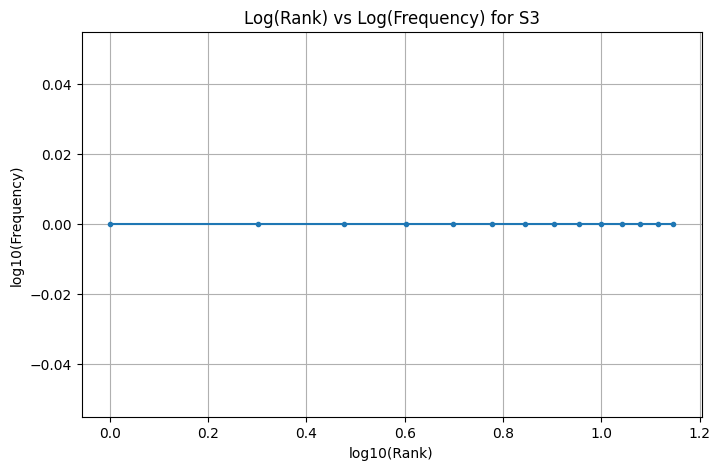



TOP 5 BIGRAMS - S1


,Bigram,Frequency
0,t01 t02,1
1,t02 t03,1
2,t03 t04,1
3,t04 t05,1
4,t05 t06,1




TOP 5 BIGRAMS - S3


,Bigram,Frequency
0,t01 t02,1
1,t02 t03,1
2,t03 t04,1
3,t04 t05,1
4,t05 t06,1




FINAL SUMMARY

S1 - All Tokens
Total: 14
Unique: 14
TTR: 1.0

S2 - Tokens Without Punctuation
Total: 14
Unique: 14
TTR: 1.0

S3 - Final Tokens
Total: 14
Unique: 14
TTR: 1.0

S4 - Porter Stemmed
Total: 14
Unique: 14
TTR: 1.0


In [16]:
# ============================================================
# Q5 - CORPUS STATISTICS
# ============================================================

import re
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from nltk.stem import PorterStemmer


# ============================================================
# 1. CREATE S1, S2, S3
# ============================================================

S1 = []   # All tokens
S2 = []   # Tokens without punctuation
S3 = []   # Final tokens


# ------------------------------------------------------------
# IMPORTANT:
# tickets is a DataFrame, so use iterrows()
# ------------------------------------------------------------

for _, row in tickets.iterrows():

    # Find the ticket text
    if "text" in row.index:
        ticket_text = row["text"]

    elif "ticket" in row.index:
        ticket_text = row["ticket"]

    elif "description" in row.index:
        ticket_text = row["description"]

    elif "body" in row.index:
        ticket_text = row["body"]

    else:
        # Find the first string column
        ticket_text = None

        for value in row:
            if isinstance(value, str):
                ticket_text = value
                break

        if ticket_text is None:
            continue

    # Process ticket using the given function
    result = process_ticket(ticket_text)

    # --------------------------------------------------------
    # S1 = all tokens
    # --------------------------------------------------------

    S1.extend(result["tokens"])

    # --------------------------------------------------------
    # S2 = tokens without punctuation
    # --------------------------------------------------------

    punctuation = set(result["punct"])

    for token in result["tokens"]:
        if token not in punctuation:
            S2.append(token)

    # --------------------------------------------------------
    # S3 = final tokens
    # --------------------------------------------------------

    S3.extend(result["final"])


# ============================================================
# 2. S4 = PORTER STEMMED FINAL TOKENS
# ============================================================

porter = PorterStemmer()

S4 = [
    porter.stem(str(token))
    for token in S3
]


# ============================================================
# 3. FUNCTION TO CALCULATE CORPUS STATISTICS
# ============================================================

def corpus_statistics(tokens):

    total_tokens = len(tokens)

    unique_tokens = len(set(tokens))

    if total_tokens > 0:
        ttr = unique_tokens / total_tokens
    else:
        ttr = 0

    return total_tokens, unique_tokens, ttr


# ============================================================
# 4. CALCULATE STATISTICS FOR S1-S4
# ============================================================

stats = []

for name, corpus in [
    ("S1 - All Tokens", S1),
    ("S2 - Without Punctuation", S2),
    ("S3 - Final Tokens", S3),
    ("S4 - Porter Stemmed", S4)
]:

    total, unique, ttr = corpus_statistics(corpus)

    stats.append({
        "Corpus": name,
        "Total Tokens": total,
        "Unique Tokens": unique,
        "TTR": ttr
    })


stats_df = pd.DataFrame(stats)


# ============================================================
# 5. DISPLAY CORPUS STATISTICS
# ============================================================

print("=" * 80)
print("CORPUS STATISTICS")
print("=" * 80)

display(stats_df)


# ============================================================
# 6. TOP 10 WORDS OF S1
# ============================================================

print("\n")
print("=" * 80)
print("TOP 10 WORDS - S1")
print("=" * 80)

s1_frequency = Counter(S1)

top10_S1 = s1_frequency.most_common(10)

top10_s1_df = pd.DataFrame(
    top10_S1,
    columns=["Word", "Frequency"]
)

display(top10_s1_df)


# ============================================================
# 7. TOP 10 WORDS OF S3
# ============================================================

print("\n")
print("=" * 80)
print("TOP 10 WORDS - S3")
print("=" * 80)

s3_frequency = Counter(S3)

top10_S3 = s3_frequency.most_common(10)

top10_s3_df = pd.DataFrame(
    top10_S3,
    columns=["Word", "Frequency"]
)

display(top10_s3_df)


# ============================================================
# 8. LOG(RANK) vs LOG(FREQUENCY) FOR S3
# ============================================================

# Sort frequencies from highest to lowest
s3_ranked = s3_frequency.most_common()

ranks = list(range(1, len(s3_ranked) + 1))

frequencies = [
    frequency
    for word, frequency in s3_ranked
]


# Calculate logs
import math

log_ranks = [
    math.log10(rank)
    for rank in ranks
]

log_frequencies = [
    math.log10(freq)
    for freq in frequencies
]


# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    log_ranks,
    log_frequencies,
    marker="o",
    markersize=3
)

plt.xlabel("log10(Rank)")
plt.ylabel("log10(Frequency)")
plt.title("Log(Rank) vs Log(Frequency) for S3")

plt.grid(True)

plt.show()


# ============================================================
# 9. TOP 5 BIGRAMS - S1
# ============================================================

def get_bigrams(tokens):

    return [
        (tokens[i], tokens[i + 1])
        for i in range(len(tokens) - 1)
    ]


s1_bigrams = get_bigrams(S1)

s1_bigram_frequency = Counter(s1_bigrams)

top5_S1_bigrams = s1_bigram_frequency.most_common(5)


print("\n")
print("=" * 80)
print("TOP 5 BIGRAMS - S1")
print("=" * 80)

top5_s1_bigram_df = pd.DataFrame(
    [
        (" ".join(bigram), frequency)
        for bigram, frequency in top5_S1_bigrams
    ],
    columns=["Bigram", "Frequency"]
)

display(top5_s1_bigram_df)


# ============================================================
# 10. TOP 5 BIGRAMS - S3
# ============================================================

s3_bigrams = get_bigrams(S3)

s3_bigram_frequency = Counter(s3_bigrams)

top5_S3_bigrams = s3_bigram_frequency.most_common(5)


print("\n")
print("=" * 80)
print("TOP 5 BIGRAMS - S3")
print("=" * 80)

top5_s3_bigram_df = pd.DataFrame(
    [
        (" ".join(bigram), frequency)
        for bigram, frequency in top5_S3_bigrams
    ],
    columns=["Bigram", "Frequency"]
)

display(top5_s3_bigram_df)


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print("\nS1 - All Tokens")
print("Total:", len(S1))
print("Unique:", len(set(S1)))
print("TTR:", len(set(S1)) / len(S1) if S1 else 0)

print("\nS2 - Tokens Without Punctuation")
print("Total:", len(S2))
print("Unique:", len(set(S2)))
print("TTR:", len(set(S2)) / len(S2) if S2 else 0)

print("\nS3 - Final Tokens")
print("Total:", len(S3))
print("Unique:", len(set(S3)))
print("TTR:", len(set(S3)) / len(S3) if S3 else 0)

print("\nS4 - Porter Stemmed")
print("Total:", len(S4))
print("Unique:", len(set(S4)))
print("TTR:", len(set(S4)) / len(S4) if S4 else 0)

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*(a) TTR changes because stemming combines different word forms into common stems, reducing unique tokens.
(b) isn't may stay as one token in my tokenizer but gets split by word_tokenize() because of contraction handling.
(c) Stemming studies to studi is undesirable because studi is not a real English word.
(d) POS-aware lemmatization converts studies to study, preserving meaning better than stemming.